# Import Libraries

In [1]:
import numpy as np
import pandas as pd 

### Data loading

In [2]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')

In [3]:
df.shape

(533948, 9)

In [4]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


In [5]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState'],
      dtype='object')

In [6]:
df.nunique()

ProductFamily             1
Order_ID             479881
OrderDate              3103
SKU_Description          20
WareHouseQuantity        13
SKU                      21
SKU_Category              3
Channel                  34
ShipToState              88
dtype: int64

In [7]:
df.isna().sum()

ProductFamily          0
Order_ID               0
OrderDate              0
SKU_Description      544
WareHouseQuantity      0
SKU                    0
SKU_Category         544
Channel               12
ShipToState           92
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(533300, 9)

### Feature Engineering

In [10]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [11]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState,Week,Month,Year
0,AIRD,62181848,2022-12-19,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA,2022-12-19,12,2022
1,AIRD,60849149,2021-07-08,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA,2021-07-05,7,2021
2,AIRD,60849335,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR,2021-07-05,7,2021
3,AIRD,60849349,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT,2021-07-05,7,2021
4,AIRD,60849449,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD,2021-07-05,7,2021


### Range Of SKU's

In [12]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [13]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2025-07-28 00:00:00


### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : April, May, June 2025
- For Training : Sep 22 to March 31

In [14]:
import pandas as pd
from dateutil.relativedelta import relativedelta


# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# -----------------------
# Split Test & Train
# -----------------------

# Test Data: April, May, June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before April 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]


# -----------------------
# TRAIN DATA RANGE INFO
# -----------------------
# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")


print("\nTrain Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))




Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13

Train Data:
     Week_Start   Week_End  WareHouseQuantity
786  2022-09-12 2022-09-18                  1
801  2022-09-26 2022-10-02                  5
821  2022-10-17 2022-10-23                 17
831  2022-10-24 2022-10-30                 84
842  2022-10-31 2022-11-06                125
...         ...        ...                ...
1891 2025-02-24 2025-03-02                398
1902 2025-03-03 2025-03-09                447
1912 2025-03-10 2025-03-16                482
1922 2025-03-17 2025-03-23                596
1931 2025-03-24 2025-03-30                721

[130 rows x 3 columns]

Test Data:
     Week_Start   Week_End  WareHouseQuantity
1950 2025-04-07 2025-04-13                738
1959 2025-04-14 2025-04-20                432
1968 2025-04-21 2025-04-27                541
197

### Prophet Model r2_score=0.27

c:\forecasting\datasets\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


22:00:24 - cmdstanpy - INFO - Chain [1] start processing
22:00:24 - cmdstanpy - INFO - Chain [1] done processing


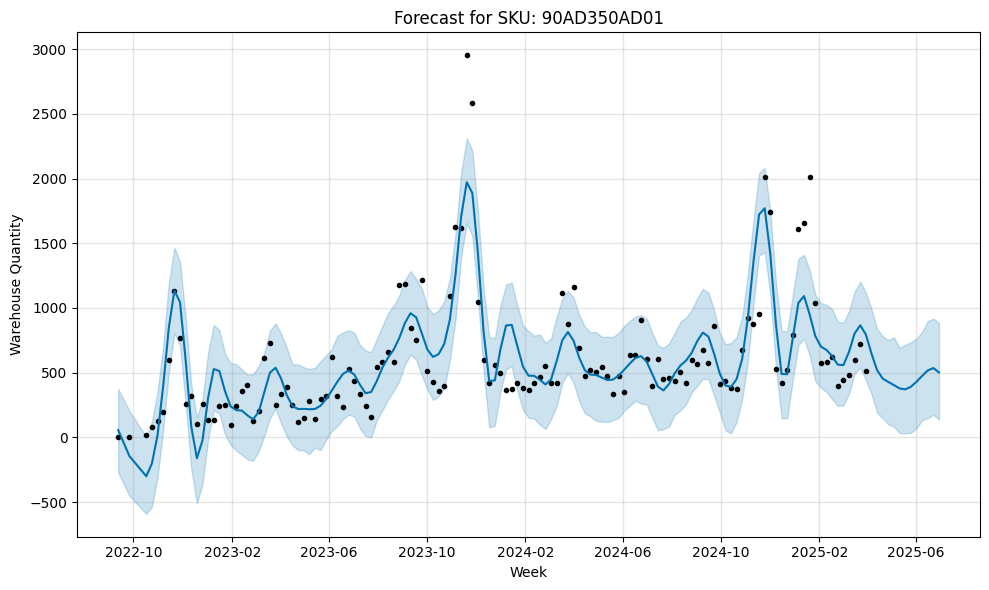

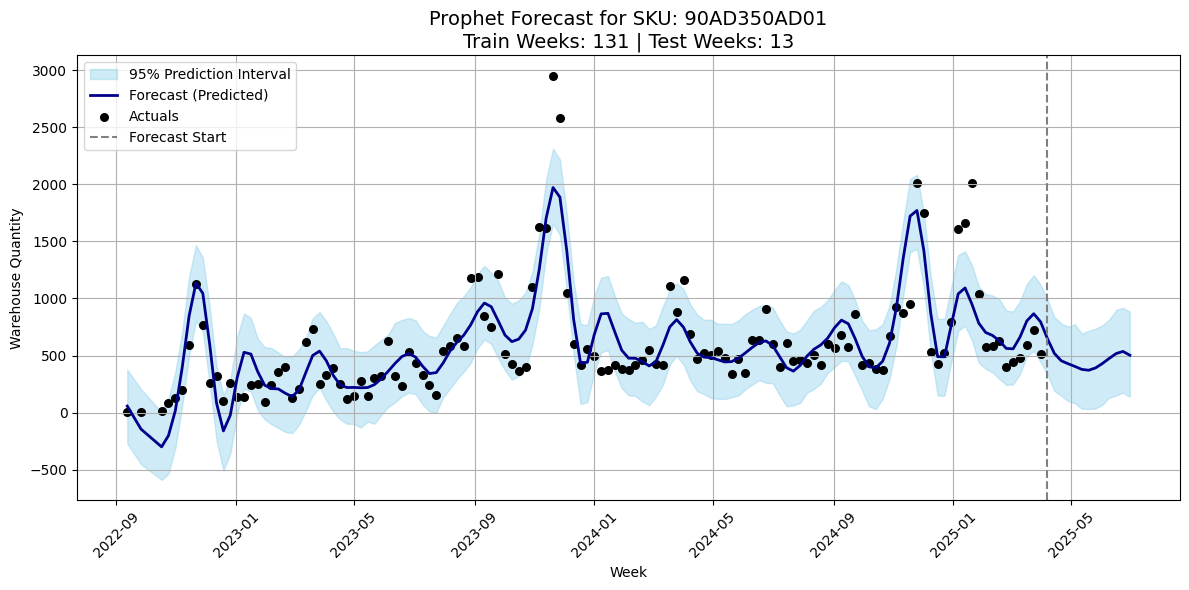


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  647.371748
132 2025-04-14              432.0  519.038459
133 2025-04-21              541.0  454.013202
134 2025-04-28              509.0  428.065072
135 2025-05-05              506.0  404.106412
136 2025-05-12              486.0  378.446411
137 2025-05-19              318.0  371.013167
138 2025-05-26              414.0  391.331609
139 2025-06-02              375.0  430.023210
140 2025-06-09              474.0  475.105984
141 2025-06-16              475.0  517.095288
142 2025-06-23              390.0  535.840302
143 2025-06-30              388.0  502.380065

Accuracy Metrics:
MAE  (Mean Absolute Error):        76.09
MSE  (Mean Squared Error):         7256.43
RMSE (Root Mean Squared Error):    85.18
MAPE (Mean Absolute % Error):      16.88%
R²   (R-squared Score):            0.27


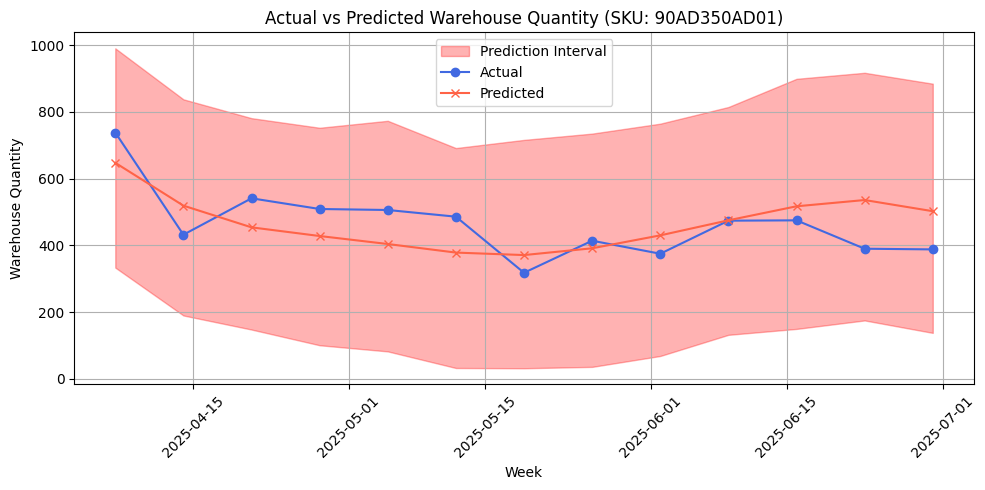


Final Forecast Results with Rounded Predictions:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference
131,2025-04-07,2025-04-13,738.0,647,-90.628252,-12.28%
132,2025-04-14,2025-04-20,432.0,519,87.038459,20.15%
133,2025-04-21,2025-04-27,541.0,454,-86.986798,-16.08%
134,2025-04-28,2025-05-04,509.0,428,-80.934928,-15.9%
135,2025-05-05,2025-05-11,506.0,404,-101.893588,-20.14%
136,2025-05-12,2025-05-18,486.0,378,-107.553589,-22.13%
137,2025-05-19,2025-05-25,318.0,371,53.013167,16.67%
138,2025-05-26,2025-06-01,414.0,391,-22.668391,-5.48%
139,2025-06-02,2025-06-08,375.0,430,55.023210,14.67%
140,2025-06-09,2025-06-15,474.0,475,1.105984,0.23%


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    # weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=0.0010529503714950096
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)


# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Show final result
print("\nFinal Forecast Results with Rounded Predictions:")
final_result


### r2_score=0.31       
- `yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=5.0,
    holidays_prior_scale=0.00801378512898308`

22:07:06 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


22:07:06 - cmdstanpy - INFO - Chain [1] done processing


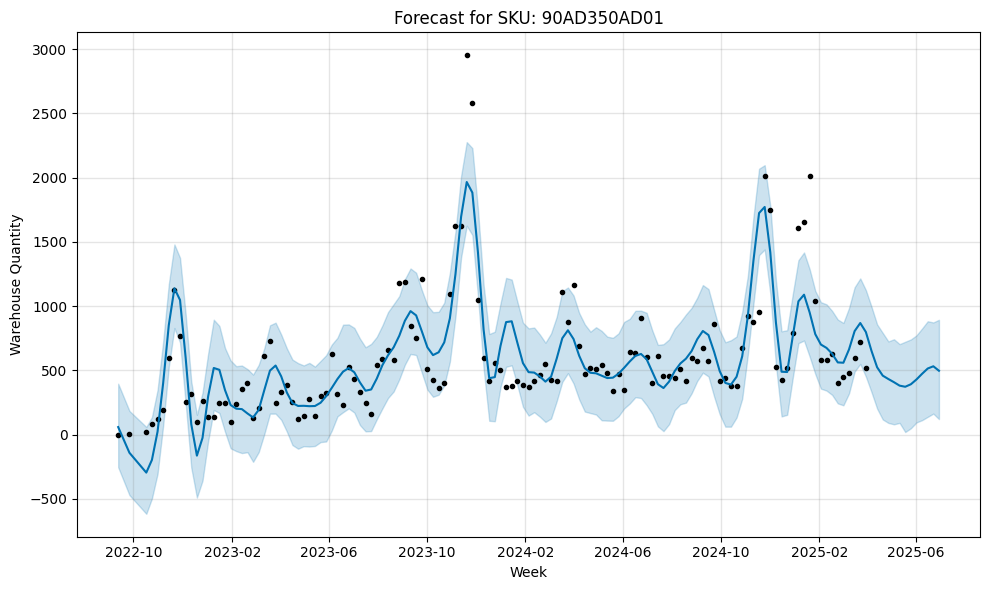

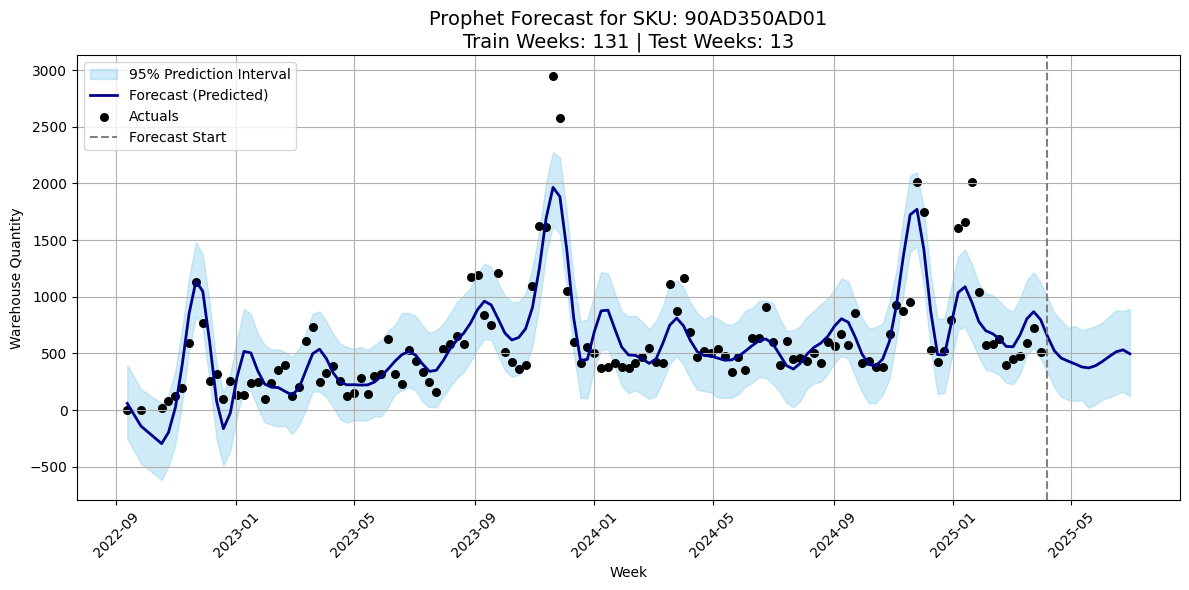


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  651.795211
132 2025-04-14              432.0  524.103811
133 2025-04-21              541.0  459.156536
134 2025-04-28              509.0  432.769425
135 2025-05-05              506.0  408.027363
136 2025-05-12              486.0  381.333974
137 2025-05-19              318.0  372.684672
138 2025-05-26              414.0  391.943756
139 2025-06-02              375.0  429.402024
140 2025-06-09              474.0  473.560427
141 2025-06-16              475.0  514.514797
142 2025-06-23              390.0  531.969645
143 2025-06-30              388.0  497.193854

Accuracy Metrics:
MAE  (Mean Absolute Error):        73.94
MSE  (Mean Squared Error):         6850.32
RMSE (Root Mean Squared Error):    82.77
MAPE (Mean Absolute % Error):      16.46%
R²   (R-squared Score):            0.31


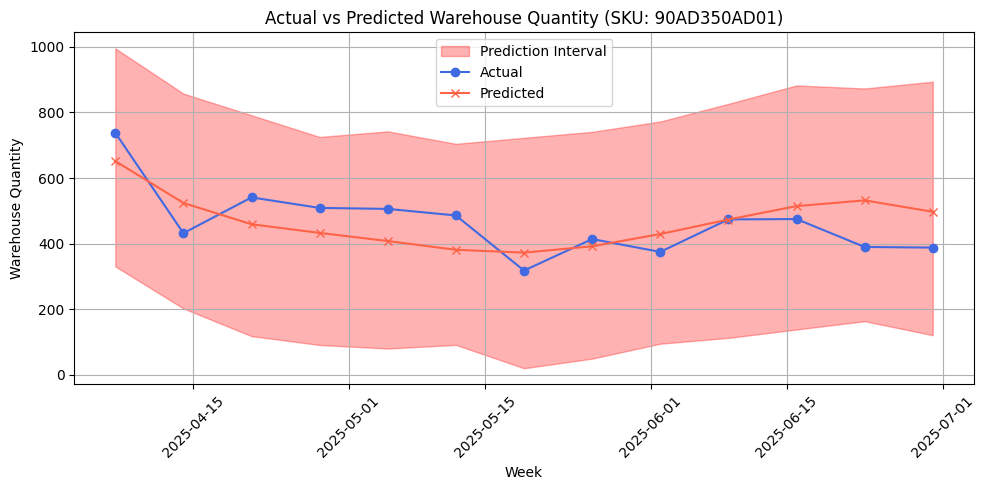


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
131,2025-04-07,2025-04-13,738.0,652,-86.204789,-11.68%,664,812,Out of Range
132,2025-04-14,2025-04-20,432.0,524,92.103811,21.32%,389,475,Out of Range
133,2025-04-21,2025-04-27,541.0,459,-81.843464,-15.13%,487,595,Out of Range
134,2025-04-28,2025-05-04,509.0,433,-76.230575,-14.98%,458,560,Out of Range
135,2025-05-05,2025-05-11,506.0,408,-97.972637,-19.36%,455,557,Out of Range
136,2025-05-12,2025-05-18,486.0,381,-104.666026,-21.54%,437,535,Out of Range
137,2025-05-19,2025-05-25,318.0,373,54.684672,17.2%,286,350,Out of Range
138,2025-05-26,2025-06-01,414.0,392,-22.056244,-5.33%,373,455,Acceptable
139,2025-06-02,2025-06-08,375.0,429,54.402024,14.51%,338,413,Out of Range
140,2025-06-09,2025-06-15,474.0,474,-0.439573,-0.09%,427,521,Acceptable


In [17]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=5.0,
    holidays_prior_scale=0.00801378512898308
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# STEP 10: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

# Convert to readable format
final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})

# Accuracy within ±10% band
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# Display final results
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("forecast_results_with_10_percent_band.csv", index=False)
final_result
